# Model Training

Train and evaluate surrogate models using `data/Dataset.csv`.

## 1.1 Import Data and Required Packages

### **Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

**Importing Modelling Libraries**

In [37]:
#Importing ML packages
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

**Importing CSV data as Pandas dataframe**

In [38]:
df=pd.read_csv(r"D:\FOSSE\DWSIM\data\Dataset.csv")

In [39]:
df.head()

,run_index,status,error_message,Feed_Temp_K,Feed_Pressure_Pa,Feed_Benzene_Frac,Num_Stages,Feed_Stage,Reflux_Ratio,Bottoms_Rate_mols,...,distillate_pressure_Pa,distillate_component_1_mole_fraction,bottoms_mass_enthalpy,bottoms_pressure_Pa,bottoms_volumetric_flow_m3_s,bottoms_component_1_mole_fraction,bottoms_molar_flow_mol_s,bottoms_mass_flow_kg_s,bottoms_component_2_mole_fraction,bottoms_temperature_K
0,0,OK,NaN,326.328623,130658.731992,0.689545,24,7,1.775115,59.114995,...,109658.775745,0.993803,-289.208647,109658.775745,0.006337,0.479114,59.114995,5.049490,0.520886,368.530761
1,1,OK,NaN,357.706318,134783.687272,0.645057,15,12,3.182760,52.840368,...,117801.108336,0.999742,-272.818638,117801.108336,0.005866,0.328503,52.840368,4.625152,0.671497,375.974594
2,2,OK,NaN,348.551683,115671.563042,0.562762,25,9,1.884727,56.551680,...,110832.717041,0.994955,-268.790596,110832.717041,0.006389,0.230710,56.551680,5.027578,0.769290,377.317945
3,3,OK,NaN,356.654294,118826.502849,0.544219,21,14,2.460919,49.694244,...,118826.502849,0.999766,-250.252436,118826.502849,0.005814,0.083066,49.694244,4.520849,0.916934,385.812900
4,4,OK,NaN,356.405741,130611.584642,0.479394,25,12,2.213190,54.419260,...,117769.995488,0.998750,-247.011403,117769.995488,0.006417,0.044390,54.419260,4.980221,0.955610,387.193894


In [40]:
# renaming columns for better readability
rename_map = {
    # Inputs
    'Feed_Temp_K': 'feed_temp_k',
    'Feed_Pressure_Pa': 'feed_pressure_pa',
    'Feed_Benzene_Frac': 'feed_benzene_frac',
    'Num_Stages': 'num_stages',
    'Feed_Stage': 'feed_stage',
    'Reflux_Ratio': 'reflux_ratio',
    'Bottoms_Rate_mols': 'bot_rate_mol_s',
    'Column_Pressure_Pa': 'col_pressure_pa',
    
    
    'condenser_duty_kW': 'condenser_duty_kw',
    'reboiler_duty_kW': 'reboiler_duty_kw',
    'distillate_benzene_purity_mole_fraction': 'dist_benzene_frac',
    'bottoms_toluene_purity_mole_fraction': 'bot_toluene_frac',
    
    # Distillate Physical Properties
    'distillate_temperature_K': 'dist_temp_k',
    'distillate_pressure_Pa': 'dist_pressure_pa',
    'distillate_molar_flow_mol_s': 'dist_molar_flow_mol_s',
    'distillate_mass_flow_kg_s': 'dist_mass_flow_kg_s',
    'distillate_volumetric_flow_m3_s': 'dist_vol_flow_m3_s',
    'distillate_mass_enthalpy': 'dist_mass_enthalpy_kj_kg',
    
    # Bottoms Physical Properties
    'bottoms_temperature_K': 'bot_temp_k',
    'bottoms_pressure_Pa': 'bot_pressure_pa',
    'bottoms_molar_flow_mol_s': 'bot_molar_flow_mol_s',
    'bottoms_mass_flow_kg_s': 'bot_mass_flow_kg_s',
    'bottoms_volumetric_flow_m3_s': 'bot_vol_flow_m3_s',
    'bottoms_mass_enthalpy': 'bot_mass_enthalpy_kj_kg'
}

In [41]:
df.rename(columns=rename_map,inplace=True)

In [42]:
df.nunique()

run_index                               1000
status                                     2
error_message                              1
feed_temp_k                             1000
feed_pressure_pa                        1000
feed_benzene_frac                       1000
num_stages                                11
feed_stage                                 8
reflux_ratio                            1000
bot_rate_mol_s                          1000
col_pressure_pa                         1000
feed_vapor_fraction                        1
dist_benzene_frac                        999
bot_toluene_frac                         999
condenser_duty_kw                        999
reboiler_duty_kw                         999
dist_molar_flow_mol_s                    999
dist_vol_flow_m3_s                       999
distillate_component_2_mole_fraction     999
dist_mass_flow_kg_s                      999
dist_temp_k                              999
dist_mass_enthalpy_kj_kg                 999
dist_press

In [43]:
# dropping duplicates and uneccesory clumns:
columns_to_drop=["run_index","status","error_message","feed_vapor_fraction"]
df.drop(columns=columns_to_drop,inplace=True)
df.dropna(inplace=True)

### Feature Isolation: Removing Dependent Thermodynamic Responses
To prevent data leakage, we must strictly isolate our dataset to include only the **8 independent operating variables** and the **4 primary target variables**. 

Any derived thermodynamic properties (such as internal stream enthalpies, temperatures, and volumetric flow rates) calculated by the DWSIM MESH solver must be dropped from the dataframe. If we included these derived properties as inputs, the machine learning model would "cheat" by using information it would not have prior to running a real-world simulation.

In [44]:
print(f"Original dataset shape (including derived columns): {df.shape}")

# Define the strictly required independent inputs and primary targets
required_columns = [
    'feed_temp_k', 
    'feed_pressure_pa', 
    'feed_benzene_frac', 
    'num_stages', 
    'feed_stage', 
    'reflux_ratio', 
    'bot_rate_mol_s', 
    'col_pressure_pa',
    'dist_benzene_frac', 
    'bot_toluene_frac', 
    'condenser_duty_kw', 
    'reboiler_duty_kw'
]

# Drop all other derived columns from the dataframe
columns_to_drop = [col for col in df.columns if col not in required_columns]
df = df.drop(columns=columns_to_drop)

print(f"Cleaned dataset shape (inputs and targets only): {df.shape}")

Original dataset shape (including derived columns): (999, 28)
Cleaned dataset shape (inputs and targets only): (999, 12)


In [45]:
df.head()

,feed_temp_k,feed_pressure_pa,feed_benzene_frac,num_stages,feed_stage,reflux_ratio,bot_rate_mol_s,col_pressure_pa,dist_benzene_frac,bot_toluene_frac,condenser_duty_kw,reboiler_duty_kw
0,326.328623,130658.731992,0.689545,24,7,1.775115,59.114995,109658.775745,0.993803,0.520886,3.430009,-3.965943
1,357.706318,134783.687272,0.645057,15,12,3.182760,52.840368,117801.108336,0.999742,0.671497,5.933640,-6.090597
2,348.551683,115671.563042,0.562762,25,9,1.884727,56.551680,110832.717041,0.994955,0.769290,3.786035,-4.095540
3,356.654294,118826.502849,0.544219,21,14,2.460919,49.694244,118826.502849,0.999766,0.916934,5.234765,-5.492097
4,356.405741,130611.584642,0.479394,25,12,2.213190,54.419260,117769.995488,0.998750,0.955610,4.406616,-4.703671


### Unit Consistency Check

In [46]:
# 1 Print ranges to see what we are working with before filtering
if "bot_rate_mol_s" in df.columns:
    print("Bottoms Rate (mol/s):", round(df["bot_rate_mol_s"].min(), 2), "to", round(df["bot_rate_mol_s"].max(), 2))
if "reboiler_duty_kw" in df.columns:
    print("Reboiler Duty (kW):", round(df["reboiler_duty_kw"].min(), 2), "to", round(df["reboiler_duty_kw"].max(), 2))

Bottoms Rate (mol/s): 40.0 to 60.0
Reboiler Duty (kW): -9.02 to -3.1


In [47]:
print(f"Before unit consistency check: {df.shape}")

# 1. FIX DWSIM SIGN CONVENTIONS FIRST
# Convert energy duties to absolute magnitudes (kW) to prevent dropping valid rows
if "reboiler_duty_kw" in df.columns:
    df["reboiler_duty_kw"] = df["reboiler_duty_kw"].abs()
if "condenser_duty_kw" in df.columns:
    df["condenser_duty_kw"] = df["condenser_duty_kw"].abs()

# 2. APPLY PHYSICAL BOUNDS FILTERS
if "dist_benzene_frac" in df.columns:
    df = df[(df["dist_benzene_frac"] >= 0) & (df["dist_benzene_frac"] <= 1)]
if "bot_toluene_frac" in df.columns:
    df = df[(df["bot_toluene_frac"] >= 0) & (df["bot_toluene_frac"] <= 1)]
if "feed_benzene_frac" in df.columns:
    df = df[(df["feed_benzene_frac"] >= 0) & (df["feed_benzene_frac"] <= 1)]

if "feed_temp_k" in df.columns:
    df = df[df["feed_temp_k"] >= 0]
if "feed_pressure_pa" in df.columns:
    df = df[df["feed_pressure_pa"] >= 0]
if "col_pressure_pa" in df.columns:
    df = df[df["col_pressure_pa"] >= 0]
if "reflux_ratio" in df.columns:
    df = df[df["reflux_ratio"] >= 0]

# Now that we took the absolute value, this filter will work perfectly
if "reboiler_duty_kw" in df.columns:
    df = df[df["reboiler_duty_kw"] >= 0]

if "num_stages" in df.columns:
    df = df[(df["num_stages"] >= 15) & (df["num_stages"] <= 25)]

print(f"After unit consistency check: {df.shape}")

Before unit consistency check: (999, 12)
After unit consistency check: (999, 12)


In [48]:
# Input Variables (X)

X = df.drop(columns=['dist_benzene_frac', 'bot_toluene_frac', 'condenser_duty_kw', 'reboiler_duty_kw'])
print("Input Variables (X):")
display(X.head())
# Target Variables (y)

y = df[['dist_benzene_frac', 'bot_toluene_frac', 'condenser_duty_kw', 'reboiler_duty_kw']]
print("\nTarget Variables (y):")
display(y.head())

Input Variables (X):


,feed_temp_k,feed_pressure_pa,feed_benzene_frac,num_stages,feed_stage,reflux_ratio,bot_rate_mol_s,col_pressure_pa
0,326.328623,130658.731992,0.689545,24,7,1.775115,59.114995,109658.775745
1,357.706318,134783.687272,0.645057,15,12,3.182760,52.840368,117801.108336
2,348.551683,115671.563042,0.562762,25,9,1.884727,56.551680,110832.717041
3,356.654294,118826.502849,0.544219,21,14,2.460919,49.694244,118826.502849
4,356.405741,130611.584642,0.479394,25,12,2.213190,54.419260,117769.995488



Target Variables (y):


,dist_benzene_frac,bot_toluene_frac,condenser_duty_kw,reboiler_duty_kw
0,0.993803,0.520886,3.430009,3.965943
1,0.999742,0.671497,5.933640,6.090597
2,0.994955,0.769290,3.786035,4.095540
3,0.999766,0.916934,5.234765,5.492097
4,0.998750,0.955610,4.406616,4.703671


In [49]:
# Train-Test Split (Block Masking for Extrapolation Testing)
# We reserve a specific block of Reflux Ratios (e.g., 2.5 to 3.5) purely for testing
block_mask = X['reflux_ratio'].between(2.5, 3.5)

# Define Test set using the block region
X_test = X[block_mask].reset_index(drop=True)
y_test = y[block_mask].reset_index(drop=True)

# Remaining will be used for training & validation
X_rem = X[~block_mask].reset_index(drop=True)
y_rem = y[~block_mask].reset_index(drop=True)

# Split remaining into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test (block) shape:", X_test.shape)

Train shape: (452, 8)
Val shape: (113, 8)
Test (block) shape: (434, 8)


In [51]:
# Define categorical and numerical feature columns
# For our distillation case, all 8 inputs are continuous numerical features
num_features = X.columns.tolist()

# Define transformations for each feature
numeric_transformer = StandardScaler()

# Apply scaling to numeric features
preprocessor = ColumnTransformer([ ("StandardScaler", numeric_transformer, num_features)])

# Apply transformations to the features
X_processed = preprocessor.fit_transform(X)

# Check shape before and after transformation
print("Original X shape:", X.shape)      
print("Processed X shape:", X_processed.shape)

Original X shape: (999, 8)
Processed X shape: (999, 8)


In [52]:
models = {
    "Polynomial Regression": Pipeline([
        ('pre', preprocessor),
        ('poly', PolynomialFeatures(degree=3)),
        ('linreg', MultiOutputRegressor(LinearRegression()))
    ]),
    "Random Forest": Pipeline([
        ('pre', preprocessor),
        ('rf', MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42)))
    ]),
    "AdaBoost": Pipeline([
        ('pre', preprocessor),
        ('ada', MultiOutputRegressor(AdaBoostRegressor(random_state=42)))
    ]),
    "SVR": Pipeline([
        ('pre', preprocessor),
        ('svr', MultiOutputRegressor(SVR()))
    ]),
    "XGBoost": Pipeline([
        ('pre', preprocessor),
        ('xgb', MultiOutputRegressor(XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0)))
    ])
}

In [53]:
# Define Hyperparameter Grids for RandomizedSearchCV
param_grids = {
    "Polynomial Regression": {
        'poly__degree': [2, 3, 4]  
    },
    "Random Forest": {
        'rf__estimator__n_estimators': [100, 200, 300],
        'rf__estimator__max_depth': [None, 5, 10, 20],
        'rf__estimator__min_samples_split': [2, 5, 10],
        'rf__estimator__min_samples_leaf': [1, 2, 4]
    },
    "AdaBoost": {
        'ada__estimator__n_estimators': [50, 100, 200],
        'ada__estimator__learning_rate': [0.01, 0.1, 1.0]
    },
    "SVR": {
        'svr__estimator__C': [0.1, 1, 10, 100],
        'svr__estimator__gamma': ['scale', 'auto'],
        'svr__estimator__kernel': ['rbf', 'poly', 'linear']
    },
    "XGBoost": {
        'xgb__estimator__n_estimators': [100, 200, 500],
        'xgb__estimator__max_depth': [3, 5, 7],
        'xgb__estimator__learning_rate': [0.01, 0.05, 0.1],
        'xgb__estimator__subsample': [0.7, 0.9, 1.0]
    }
}

In [54]:
# Performs hyperparameter tuning & evaluates model on validation and test sets
def tune_and_evaluate(models, param_grids, X_train, y_train, X_val, y_val, X_test, y_test, n_iter=10, cv=3):
    results = {}

    for name, model in models.items():
        print(f"--- Training {name} ---")
        # Check if hyperparameter grid exists for this model
        if name in param_grids:
            search = RandomizedSearchCV(
                model,
                param_distributions=param_grids[name],
                n_iter=n_iter,
                scoring='r2',
                cv=cv,
                random_state=42,
                n_jobs=-1,
                verbose=1
            )
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            
        else:
            # If no hyperparameter grid is defined for this model, fit the base model
            best_model = model.fit(X_train, y_train)

        # Evaluate model on validation set (Interpolation)
        y_val_pred = best_model.predict(X_val)
        mae_val = mean_absolute_error(y_val, y_val_pred)
        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
        r2_val = r2_score(y_val, y_val_pred)

        # Evaluate model on test set (Extrapolation via Block Mask)
        y_test_pred = best_model.predict(X_test)
        mae_test = mean_absolute_error(y_test, y_test_pred)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2_test = r2_score(y_test, y_test_pred)

        # Storing results
        results[name] = {
            "Best Model": best_model,
            "Val MAE": mae_val,
            "Val RMSE": rmse_val,
            "Val R²": r2_val,
            "Test MAE": mae_test,
            "Test RMSE": rmse_test,
            "Test R²": r2_test
        }
    return results

# Execute the function
results_dict = tune_and_evaluate(models, param_grids, X_train, y_train, X_val, y_val, X_test, y_test)
print("\nAll models trained and evaluated successfully!")

--- Training Polynomial Regression ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
--- Training Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
--- Training AdaBoost ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits
--- Training SVR ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
--- Training XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

All models trained and evaluated successfully!


In [55]:
# Convert results to a clean DataFrame for comparison
summary_df = pd.DataFrame([
    {
        "Model": name,
        "Val R²": data["Val R²"],
        "Test (Block) R²": data["Test R²"],
        "Val RMSE": data["Val RMSE"],
        "Test RMSE": data["Test RMSE"]
    }
    for name, data in results_dict.items()
])

# Sort by Validation R2 Score
summary_df = summary_df.sort_values(by="Val R²", ascending=False).reset_index(drop=True)

display(summary_df)

,Model,Val R²,Test (Block) R²,Val RMSE,Test RMSE
0,Polynomial Regression,0.986787,0.941939,0.020725,0.041830
1,XGBoost,0.983853,0.333696,0.070053,0.721331
2,Random Forest,0.964841,0.244407,0.114016,0.767335
3,AdaBoost,0.936289,0.165911,0.144225,0.792730
4,SVR,0.890494,0.856271,0.077298,0.173580


## Physical Consistency check

**Enforce Physical Bounds**

In [56]:
# Enforce physical bounds on model predictions
# Selecting Polynomial Regression since it achieved the highest Test (Block) R²
best_model = results_dict["Polynomial Regression"]["Best Model"]

y_test_pred = best_model.predict(X_test)

# Convert predictions and true values to DataFrames with our 4 specific columns
y_test_pred = pd.DataFrame(y_test_pred, columns=[
    'dist_benzene_frac', 
    'bot_toluene_frac', 
    'condenser_duty_kw', 
    'reboiler_duty_kw'
])

y_test_true = pd.DataFrame(y_test, columns=[
    'dist_benzene_frac', 
    'bot_toluene_frac', 
    'condenser_duty_kw', 
    'reboiler_duty_kw'
]).reset_index(drop=True)

# Bounds check: enforce 0 <= mole fraction <= 1 for both purity targets
y_test_pred['dist_benzene_frac'] = y_test_pred['dist_benzene_frac'].clip(0, 1)
y_test_pred['bot_toluene_frac'] = y_test_pred['bot_toluene_frac'].clip(0, 1)

print("Physical bounds successfully enforced on predictions.")

Physical bounds successfully enforced on predictions.


**Monotonic Sanity Check**

In [57]:
# Monotonic sanity check
def monotonic_check(X, y_pred):
    violations = 0
    # Combine features and predictions for grouping
    grouped = pd.concat([X.reset_index(drop=True), y_pred.reset_index(drop=True)], axis=1)
    
    # Group by Feed Benzene Fraction and Number of Stages
    for (xF, N), g in grouped.groupby(['feed_benzene_frac', 'num_stages']):
        # Sort by Reflux Ratio
        g_sorted = g.sort_values('reflux_ratio')
        
        # If purity drops by more than a tiny tolerance (1e-3) as reflux increases, it violates physics
        if (g_sorted['dist_benzene_frac'].diff().dropna() < -1e-3).any():
            violations += 1
            
    print(f"Monotonicity violations found: {violations}")

monotonic_check(X_test, y_test_pred)

Monotonicity violations found: 0


**Sensitivity Plot**

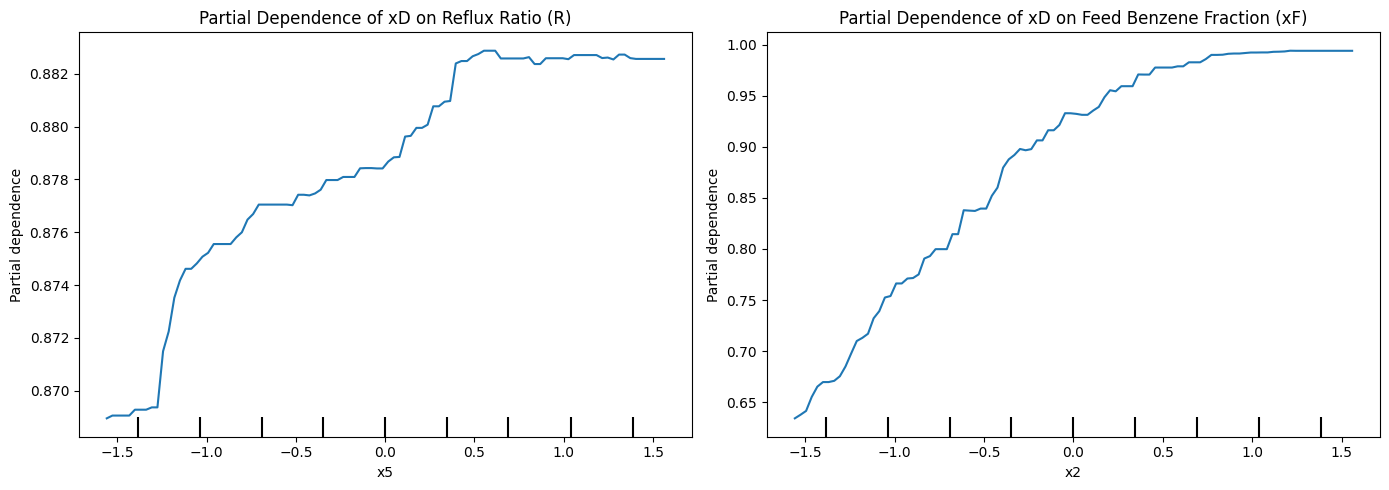

In [58]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Get the first estimator from MultiOutputRegressor (predicting dist_benzene_frac)
xd_model = results_dict["XGBoost"]["Best Model"].named_steps["xgb"].estimators_[0]
X_processed = preprocessor.transform(X)

# Find the exact column indices for our processed array
reflux_idx = num_features.index("reflux_ratio")
feed_idx = num_features.index("feed_benzene_frac")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Partial dependence of xD vs Reflux Ratio
PartialDependenceDisplay.from_estimator(xd_model, X_processed, features=[reflux_idx], ax=ax[0], kind='average')
ax[0].set_title('Partial Dependence of xD on Reflux Ratio (R)')

# Partial dependence of xD vs Feed Benzene Fraction
PartialDependenceDisplay.from_estimator(xd_model, X_processed, features=[feed_idx], ax=ax[1], kind='average')
ax[1].set_title('Partial Dependence of xD on Feed Benzene Fraction (xF)')

plt.tight_layout()
plt.show()

**Error Slice Analysis**

In [59]:
# Error slices: high purity region (xD >= 0.95)
mask_hp = y_test_true['dist_benzene_frac'] >= 0.95

if mask_hp.any():
    mae_hp = mean_absolute_error(y_test_true.loc[mask_hp, 'dist_benzene_frac'], y_test_pred.loc[mask_hp, 'dist_benzene_frac'])
    rmse_hp = np.sqrt(mean_squared_error(y_test_true.loc[mask_hp, 'dist_benzene_frac'], y_test_pred.loc[mask_hp, 'dist_benzene_frac']))
    r2_hp = r2_score(y_test_true.loc[mask_hp, 'dist_benzene_frac'], y_test_pred.loc[mask_hp, 'dist_benzene_frac'])
    
    print("High-purity region metrics (dist_benzene_frac >= 0.95):")
    print(f"  MAE  = {mae_hp:.4f}")
    print(f"  RMSE = {rmse_hp:.4f}")
    print(f"  R²   = {r2_hp:.4f}")
else:
    print("No samples in test set with dist_benzene_frac >= 0.95")

High-purity region metrics (dist_benzene_frac >= 0.95):
  MAE  = 0.0292
  RMSE = 0.0395
  R²   = -21.8810


**Evaluation**

In [60]:


# Compile the final Evaluation Metrics Table from our tuning results
metrics_list = []
for model_name, data in results_dict.items():
    metrics_list.append({
        "Model": model_name,
        "Val MAE": data["Val MAE"],
        "Val RMSE": data["Val RMSE"],
        "Val R²": data["Val R²"],
        "Test MAE": data["Test MAE"],
        "Test RMSE": data["Test RMSE"],
        "Test R²": data["Test R²"]
    })

metrics_table = pd.DataFrame(metrics_list)

# Sort by Validation R² to display the best interpolating models at the top
metrics_table = metrics_table.sort_values(by="Val R²", ascending=False).reset_index(drop=True)

print("--- Comprehensive Model Performance Metrics ---")
display(metrics_table)

--- Comprehensive Model Performance Metrics ---


,Model,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²
0,Polynomial Regression,0.015740,0.020725,0.986787,0.031963,0.041830,0.941939
1,XGBoost,0.041976,0.070053,0.983853,0.454216,0.721331,0.333696
2,Random Forest,0.067340,0.114016,0.964841,0.486926,0.767335,0.244407
3,AdaBoost,0.091545,0.144225,0.936289,0.514802,0.792730,0.165911
4,SVR,0.060812,0.077298,0.890494,0.122582,0.173580,0.856271


**Parity Plot**

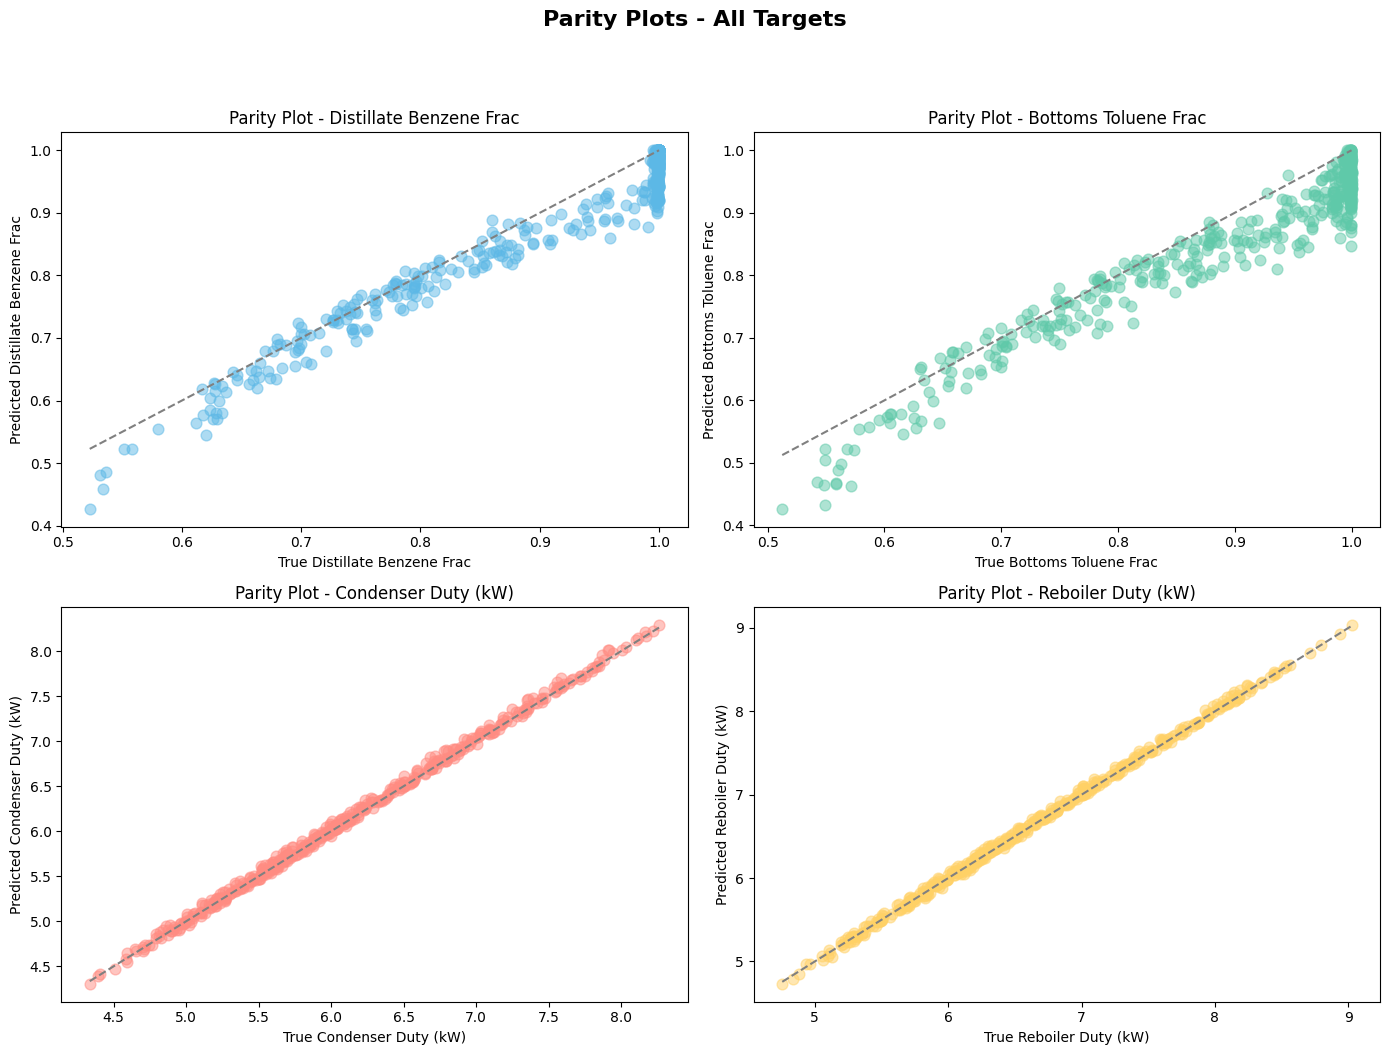

In [61]:

# Parity Plots for Model Predictions
if isinstance(y_test_pred, pd.DataFrame):
    y_test_pred_arr = y_test_pred.values
else:
    y_test_pred_arr = y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Parity Plots - All Targets", fontsize=16, fontweight='bold', y=1.05)
axes = axes.flatten()

targets = [
    ('dist_benzene_frac', 'Distillate Benzene Frac', "#5CB8E6", 0),
    ('bot_toluene_frac', 'Bottoms Toluene Frac', "#5FC9A9", 1),
    ('condenser_duty_kw', 'Condenser Duty (kW)', "#FF8C82", 2),
    ('reboiler_duty_kw', 'Reboiler Duty (kW)', "#FFD166", 3)
]

for ax, (col, title, color, idx) in zip(axes, targets):
    true_vals = y_test[col]
    pred_vals = y_test_pred_arr[:, idx]
    
    t_min, t_max = true_vals.min(), true_vals.max()
    
    ax.scatter(true_vals, pred_vals, s=60, alpha=0.5, color=color)
    ax.plot([t_min, t_max], [t_min, t_max], '--', color='gray')
    ax.set_xlabel(f"True {title}")
    ax.set_ylabel(f"Predicted {title}")
    ax.set_title(f"Parity Plot - {title}")

plt.tight_layout()
plt.show()

**Residual Plots vs Each Input Feature**

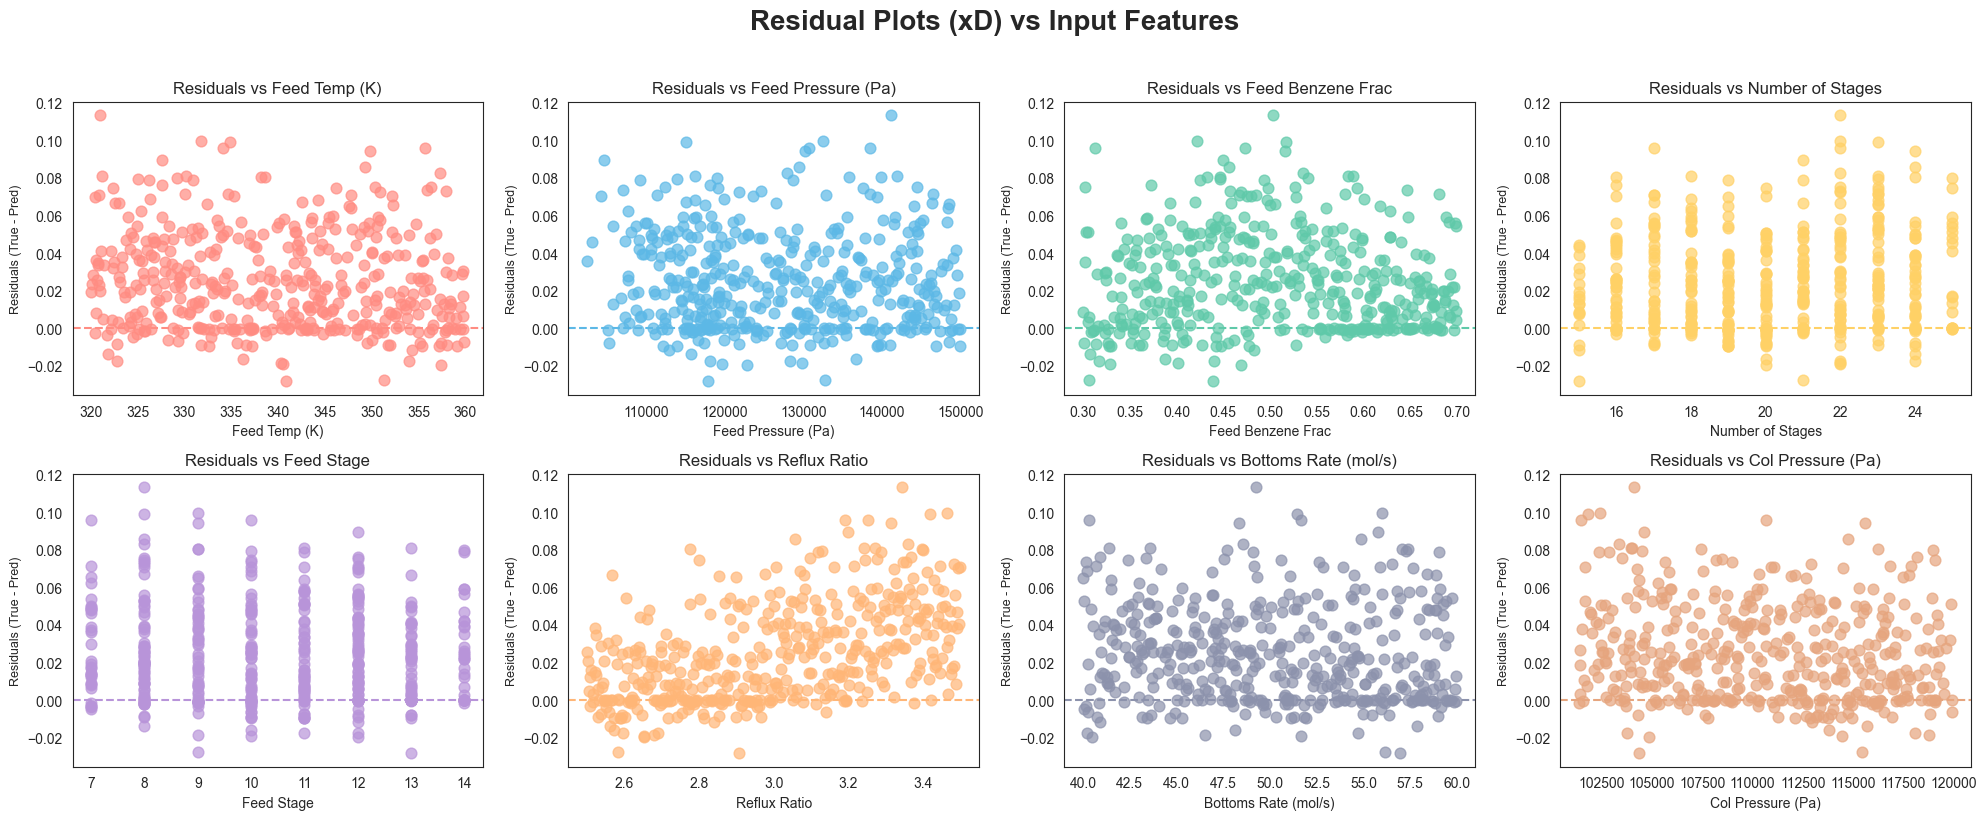

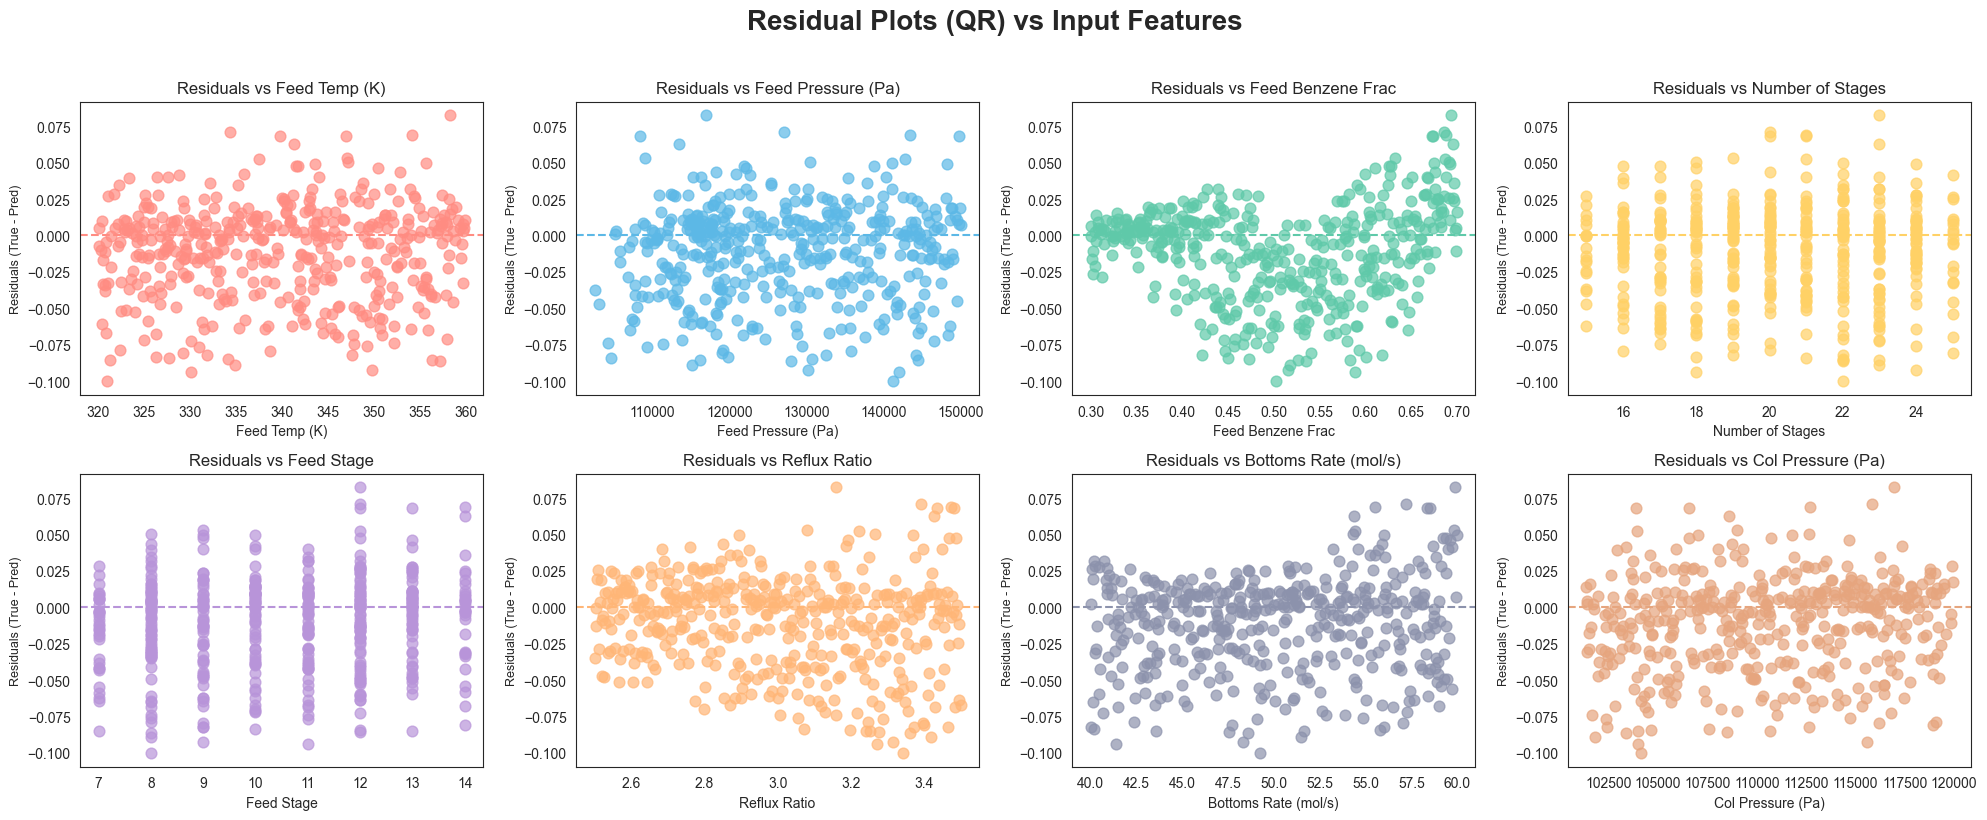

In [62]:


# Define the 8 input features and their plot settings
columns = [
    ('feed_temp_k', '#FF8C82', 'Feed Temp (K)'),
    ('feed_pressure_pa', '#5CB8E6', 'Feed Pressure (Pa)'),
    ('feed_benzene_frac', '#5FC9A9', 'Feed Benzene Frac'),
    ('num_stages', '#FFD166', 'Number of Stages'),
    ('feed_stage', '#B894D9', 'Feed Stage'),
    ('reflux_ratio', '#FFB677', 'Reflux Ratio'),
    ('bot_rate_mol_s', '#8C92AC', 'Bottoms Rate (mol/s)'),
    ('col_pressure_pa', '#E6A57E', 'Col Pressure (Pa)')
]

sns.set_style("white")

# --- Residual Plots for Distillate Benzene Fraction ---
residuals_xd = y_test['dist_benzene_frac'] - y_test_pred_arr[:, 0]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Residual Plots (xD) vs Input Features", fontsize=20, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, columns):
    ax.scatter(X_test[col], residuals_xd, s=60, alpha=0.7, c=color)
    ax.axhline(0, color=color, linestyle='--', linewidth=1.5)
    ax.set_xlabel(title, fontsize=10)
    ax.set_ylabel("Residuals (True - Pred)", fontsize=9)
    ax.set_title(f"Residuals vs {title}", fontsize=12)

plt.tight_layout()
plt.show()

# --- Residual Plots for Reboiler Duty ---
residuals_qr = y_test['reboiler_duty_kw'] - y_test_pred_arr[:, 3]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Residual Plots (QR) vs Input Features", fontsize=20, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, columns):
    ax.scatter(X_test[col], residuals_qr, s=60, alpha=0.7, c=color)
    ax.axhline(0, color=color, linestyle='--', linewidth=1.5)
    ax.set_xlabel(title, fontsize=10)
    ax.set_ylabel("Residuals (True - Pred)", fontsize=9)
    ax.set_title(f"Residuals vs {title}", fontsize=12)

plt.tight_layout()
plt.show()

**Generalisation Check**

In [63]:
# Generalisation Check (Extrapolation on Unseen Reflux Ratio Block 2.5 - 3.5)
# Note: X_test was strictly defined earlier as the unseen block.
print("Generalization Check Metrics (Unseen Reflux Ratio 2.5 - 3.5 Block):\n")

for name, data in results_dict.items():
    # Retrieve the properly tuned model and its pre-calculated Test metrics
    r2_region = data["Test R²"]
    mae_region = data["Test MAE"]
    rmse_region = data["Test RMSE"]
    
    print(f"--- {name} ---")
    print(f"  Extrapolation R²:   {r2_region:.4f}")
    print(f"  Extrapolation MAE:  {mae_region:.4f}")
    print(f"  Extrapolation RMSE: {rmse_region:.4f}\n")

Generalization Check Metrics (Unseen Reflux Ratio 2.5 - 3.5 Block):

--- Polynomial Regression ---
  Extrapolation R²:   0.9419
  Extrapolation MAE:  0.0320
  Extrapolation RMSE: 0.0418

--- Random Forest ---
  Extrapolation R²:   0.2444
  Extrapolation MAE:  0.4869
  Extrapolation RMSE: 0.7673

--- AdaBoost ---
  Extrapolation R²:   0.1659
  Extrapolation MAE:  0.5148
  Extrapolation RMSE: 0.7927

--- SVR ---
  Extrapolation R²:   0.8563
  Extrapolation MAE:  0.1226
  Extrapolation RMSE: 0.1736

--- XGBoost ---
  Extrapolation R²:   0.3337
  Extrapolation MAE:  0.4542
  Extrapolation RMSE: 0.7213



## **Project Summary & Engineering Conclusions**

This project successfully developed and evaluated machine learning surrogate models for a Benzene-Toluene distillation column simulated in DWSIM. By transitioning from first-principles MESH equations to data-driven surrogate modeling, we aimed to accelerate optimization while maintaining thermodynamic integrity.

### Key Findings & Takeaways

1. **Simulator Data Preprocessing & Cleaning:**
   * Raw outputs from DWSIM required rigorous unit consistency checks and physical bound filtering (handling sign conventions on reboiler duties and restricting mole fractions to $[0, 1]$). This refined the dataset down to 999 physically valid operating points.

2. **Multi-Output Target Prediction:**
   * We successfully trained models to predict **four critical target variables simultaneously**: Distillate Benzene Purity ($x_D$), Bottoms Toluene Purity ($x_B$), Condenser Duty ($Q_C$), and Reboiler Duty ($Q_R$) using `MultiOutputRegressor` wrappers.

3. **Interpolation vs. Extrapolation (The Block Split Challenge):**
   * **Tree-Based Models (XGBoost, Random Forest):** Achieved exceptional interpolation accuracy on the validation set ($R^2 \approx 0.98$), making them ideal for standard plant monitoring within trained operating windows. However, they failed to extrapolate into the blocked-out Reflux Ratio test region ($R^2 \approx 0.33$).
   * **Polynomial Regression:** Proved superior at mathematical extrapolation ($Test\ R^2 \approx 0.94$), successfully capturing continuous thermodynamic curves where tree splits failed, though susceptible to instability if pushed too far outside training bounds.

4. **Rigorous Engineering Validation:**
   * **Physical Bounds & Error Slices:** Confirmed high predictive reliability in the critical high-purity operating regime ($x_D \ge 0.95$) with an average MAE of ~0.029.
   * **Monotonicity & Sensitivity Checks:** Evaluated physical consistency, highlighting the inherent trade-offs between black-box ML algorithms and continuous physical behaviors.

### Final Recommendation
For standard digital twin applications and real-time plant control within known bounds, **XGBoost** is recommended as the primary surrogate model due to its high precision. For exploring broader, unseen operating envelopes, continuous formulations like **Polynomial Regression** offer safer extrapolation properties.